In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings ("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Mount Everest Accident Dataset 2020-2025.csv")
df.head()

,Date,Name,Nationality,Age,Gender,Cause_of_Death,Altitude_meters,Location,Route,Season,Weather_Conditions,Experience_Level,Expedition_Company
0,2021-07-12,Dmitri White,India,63,Male,Exhaustion,8000,Summit (8848m),Southwest Face,Summer (Jun-Aug),Snowstorm,Expert (6+ previous 8000m peaks),Peak Freaks
1,2023-06-28,Sandra Verma,Sweden,43,Male,Exhaustion,8400,Summit (8848m),North Face,Summer (Jun-Aug),Clear,Experienced (3-5 previous 8000m peaks),Alpine Ascents
2,2023-09-23,Andrew Ito,Switzerland,31,Female,Altitude Sickness (AMS/HAPE/HACE),8400,Balcony (8400m),Southwest Face,Summer (Jun-Aug),Whiteout,Experienced (3-5 previous 8000m peaks),Seven Summits Treks
3,2025-12-29,Donna Kato,Czech Republic,35,Male,Disorientation/Lost,6065,Camp 2 (6400m),South Col Route (Nepal),Winter (Dec-Feb),Extreme cold,Intermediate (1-2 previous 8000m peaks),Mountain Madness
4,2025-11-09,James Martin,Denmark,32,Male,Altitude Sickness (AMS/HAPE/HACE),8000,Lhotse Face,East Face,Autumn (Oct-Nov),Snowstorm,Intermediate (1-2 previous 8000m peaks),Climbing the Seven Summits


In [2]:
df.tail()

,Date,Name,Nationality,Age,Gender,Cause_of_Death,Altitude_meters,Location,Route,Season,Weather_Conditions,Experience_Level,Expedition_Company
495,2025-11-10,Michelle Brown,China,30,Female,Icefall,6400,Camp 2 (6400m),South Col Route (Nepal),Autumn (Oct-Nov),Snowstorm,Novice (First 8000m peak),Peak Freaks
496,2021-04-15,Alexei Watanabe,Spain,28,Female,Rockfall,8000,Lhotse Face,East Face,Spring (Apr-May),Whiteout,Professional Guide,Elite Exped
497,2022-06-11,Thomas Walker,China,28,Male,Altitude Sickness (AMS/HAPE/HACE),8790,Balcony (8400m),West Ridge,Summer (Jun-Aug),Mixed conditions,Experienced (3-5 previous 8000m peaks),Mountain Madness
498,2024-12-24,Sophie Harris,China,31,Female,Altitude Sickness (AMS/HAPE/HACE),8000,Lhotse Face,East Face,Winter (Dec-Feb),Snowstorm,Intermediate (1-2 previous 8000m peaks),Furtenbach Adventures
499,2021-03-07,Mei Popov,Russia,61,Male,Hypothermia,8400,Yellow Band,South Col Route (Nepal),Summer (Jun-Aug),High winds,Intermediate (1-2 previous 8000m peaks),Climbing the Seven Summits


Basic data info

In [3]:
df.shape

(500, 13)

In [4]:
df.columns.tolist()

['Date',
 'Name',
 'Nationality',
 'Age',
 'Gender',
 'Cause_of_Death',
 'Altitude_meters',
 'Location',
 'Route',
 'Season',
 'Weather_Conditions',
 'Experience_Level',
 'Expedition_Company']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                500 non-null    object
 1   Name                500 non-null    object
 2   Nationality         500 non-null    object
 3   Age                 500 non-null    int64 
 4   Gender              500 non-null    object
 5   Cause_of_Death      500 non-null    object
 6   Altitude_meters     500 non-null    int64 
 7   Location            500 non-null    object
 8   Route               500 non-null    object
 9   Season              500 non-null    object
 10  Weather_Conditions  500 non-null    object
 11  Experience_Level    500 non-null    object
 12  Expedition_Company  500 non-null    object
dtypes: int64(2), object(11)
memory usage: 50.9+ KB


In [6]:
df.isnull().sum()

Date                  0
Name                  0
Nationality           0
Age                   0
Gender                0
Cause_of_Death        0
Altitude_meters       0
Location              0
Route                 0
Season                0
Weather_Conditions    0
Experience_Level      0
Expedition_Company    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Check unique values

for column in df.select_dtypes(include='object').columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())


Date
Unique values: 440

Name
Unique values: 477

Nationality
Unique values: 30

Gender
Unique values: 2

Cause_of_Death
Unique values: 15

Location
Unique values: 15

Route
Unique values: 6

Season
Unique values: 4

Weather_Conditions
Unique values: 8

Experience_Level
Unique values: 6

Expedition_Company
Unique values: 16


In [9]:
# Check numeric data

print("Age range:")
print("Minimum:", df['Age'].min())
print("Maximum:", df['Age'].max())

print("\nAltitude range:")
print("Minimum:", df['Altitude_meters'].min())
print("Maximum:", df['Altitude_meters'].max())

Age range:
Minimum: 20
Maximum: 69

Altitude range:
Minimum: 5364
Maximum: 8848


In [10]:
# Check date validity

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Invalid dates:", df['Date'].isna().sum())
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())

Invalid dates: 0
Earliest date: 2020-01-05 00:00:00
Latest date: 2025-12-29 00:00:00


In [11]:
# Check text formatting

text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    whitespace_count = (
        df[column].astype(str) != df[column].astype(str).str.strip()
    ).sum()
    
    print(f"{column}: {whitespace_count} values with extra whitespace")

Name: 0 values with extra whitespace
Nationality: 0 values with extra whitespace
Gender: 0 values with extra whitespace
Cause_of_Death: 0 values with extra whitespace
Location: 0 values with extra whitespace
Route: 0 values with extra whitespace
Season: 0 values with extra whitespace
Weather_Conditions: 0 values with extra whitespace
Experience_Level: 0 values with extra whitespace
Expedition_Company: 0 values with extra whitespace


Create the cleaned dataset

In [13]:
# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# -----------------------------
# Standardise text columns
# -----------------------------
text_columns = df_clean.select_dtypes(include='object').columns

for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
    )

# -----------------------------
# Convert date
# -----------------------------
df_clean['Date'] = pd.to_datetime(
    df_clean['Date'],
    errors='coerce'
)

# -----------------------------
# Convert numeric columns
# -----------------------------
df_clean['Age'] = pd.to_numeric(
    df_clean['Age'],
    errors='coerce'
)

df_clean['Altitude_meters'] = pd.to_numeric(
    df_clean['Altitude_meters'],
    errors='coerce'
)

print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                500 non-null    datetime64[ns]
 1   Name                500 non-null    object        
 2   Nationality         500 non-null    object        
 3   Age                 500 non-null    int64         
 4   Gender              500 non-null    object        
 5   Cause_of_Death      500 non-null    object        
 6   Altitude_meters     500 non-null    int64         
 7   Location            500 non-null    object        
 8   Route               500 non-null    object        
 9   Season              500 non-null    object        
 10  Weather_Conditions  500 non-null    object        
 11  Experience_Level    500 non-null    object        
 12  Expedition_Company  500 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(10)
memory 

In [14]:
# Create Year and Month columns

df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

df_clean[['Date', 'Year', 'Month']].head()

,Date,Year,Month
0,2021-07-12,2021,7
1,2023-06-28,2023,6
2,2023-09-23,2023,9
3,2025-12-29,2025,12
4,2025-11-09,2025,11


In [15]:
# Create altitude bands

df_clean['Altitude_Band'] = pd.cut(
    df_clean['Altitude_meters'],
    bins=[0, 5999, 6999, 7999, 8848],
    labels=[
        '<6,000m',
        '6,000–6,999m',
        '7,000–7,999m',
        '8,000m+'
    ],
    include_lowest=True
)

df_clean['Altitude_Band'].value_counts().sort_index()

Altitude_Band
<6,000m          24
6,000–6,999m     76
7,000–7,999m     56
8,000m+         344
Name: count, dtype: int64

In [16]:
# Create age groups

df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 29, 39, 49, 59, 100],
    labels=[
        '20–29',
        '30–39',
        '40–49',
        '50–59',
        '60+'
    ]
)

df_clean['Age_Group'].value_counts().sort_index()

Age_Group
20–29    184
30–39    176
40–49     44
50–59     53
60+       43
Name: count, dtype: int64

In [17]:
# Create Death Zone indicator

df_clean['Death_Zone'] = np.where(
    df_clean['Altitude_meters'] >= 8000,
    'Death Zone (8,000m+)',
    'Below Death Zone'
)

df_clean['Death_Zone'].value_counts()

Death_Zone
Death Zone (8,000m+)    344
Below Death Zone        156
Name: count, dtype: int64

In [18]:
# Validate the cleaned dataset

print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nAge range:")
print(df_clean['Age'].min(), "to", df_clean['Age'].max())

print("\nAltitude range:")
print(
    df_clean['Altitude_meters'].min(),
    "to",
    df_clean['Altitude_meters'].max()
)

Shape: (500, 18)

Missing values:
Date                  0
Name                  0
Nationality           0
Age                   0
Gender                0
Cause_of_Death        0
Altitude_meters       0
Location              0
Route                 0
Season                0
Weather_Conditions    0
Experience_Level      0
Expedition_Company    0
Year                  0
Month                 0
Altitude_Band         0
Age_Group             0
Death_Zone            0
dtype: int64

Duplicate rows:
0

Age range:
20 to 69

Altitude range:
5364 to 8848


In [19]:
# Save the cleaned dataset

output_file = "Mount_Everest_Accident_Cleaned_2020_2025.csv"

df_clean.to_csv(
    output_file,
    index=False
)

print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: Mount_Everest_Accident_Cleaned_2020_2025.csv


In [20]:
# Overall statistical summary

df_clean[['Age', 'Altitude_meters']].describe().round(2)

,Age,Altitude_meters
count,500.00,500.00
mean,36.28,7789.09
std,12.52,1013.48
min,20.00,5364.00
25%,28.00,7162.00
50%,31.00,8000.00
75%,43.00,8750.00
max,69.00,8848.00


In [22]:
# Accidents by year

annual_accidents = (
    df_clean
    .groupby('Year')
    .size()
    .reset_index(name='Accidents')
)

annual_accidents

,Year,Accidents
0,2020,86
1,2021,93
2,2022,92
3,2023,86
4,2024,73
5,2025,70


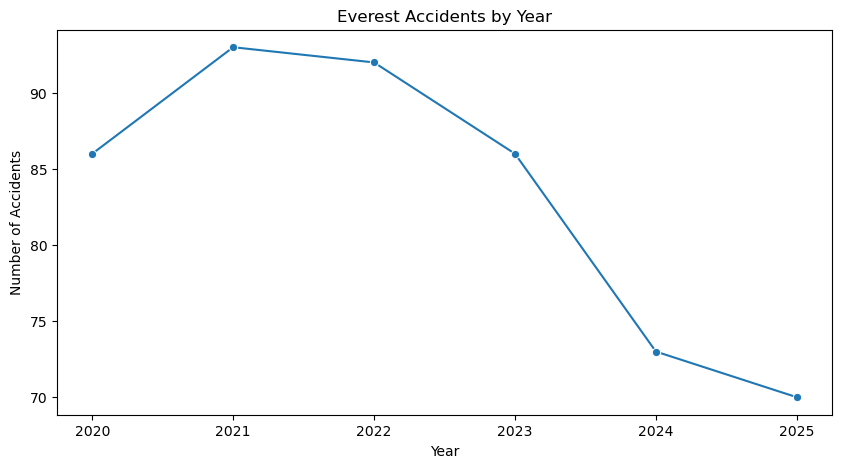

In [23]:
# Visualisation

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=annual_accidents,
    x='Year',
    y='Accidents',
    marker='o'
)

plt.title('Everest Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.savefig("Everest Accidents by Year.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# Year-on-year percentage change

annual_accidents['YoY_Change_%'] = (
    annual_accidents['Accidents']
    .pct_change() * 100
)

annual_accidents.round(1)

,Year,Accidents,YoY_Change_%
0,2020,86,NaN
1,2021,93,8.1
2,2022,92,-1.1
3,2023,86,-6.5
4,2024,73,-15.1
5,2025,70,-4.1


In [25]:
# Cause of death

cause_analysis = (
    df_clean['Cause_of_Death']
    .value_counts()
    .reset_index()
)

cause_analysis.columns = ['Cause_of_Death', 'Accidents']

cause_analysis['Percentage'] = (
    cause_analysis['Accidents'] /
    len(df_clean) * 100
)

cause_analysis

,Cause_of_Death,Accidents,Percentage
0,Altitude Sickness (AMS/HAPE/HACE),129,25.8
1,Exhaustion,81,16.2
2,Falling,58,11.6
3,Hypothermia,42,8.4
4,Avalanche,36,7.2
5,Frostbite complications,27,5.4
6,Sudden cardiac event,22,4.4
7,Cerebral edema,20,4.0
8,Crevasse fall,19,3.8
9,Icefall,16,3.2


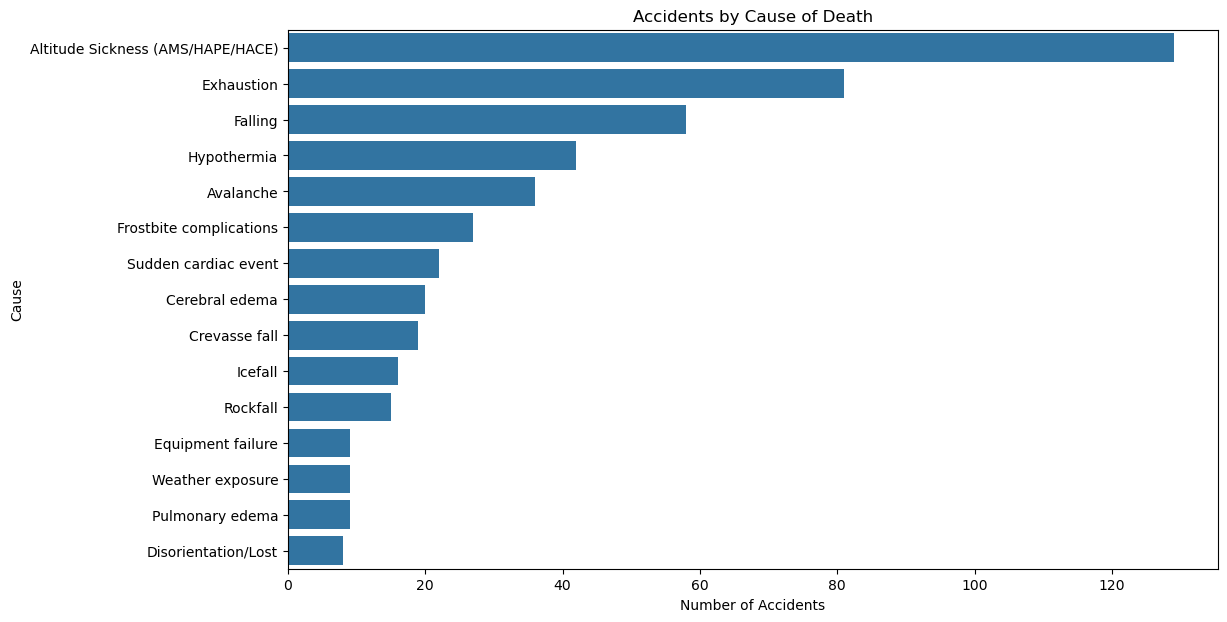

In [26]:
# Visualisation

plt.figure(figsize=(12, 7))

sns.barplot(
    data=cause_analysis,
    x='Accidents',
    y='Cause_of_Death'
)

plt.title('Accidents by Cause of Death')
plt.xlabel('Number of Accidents')
plt.ylabel('Cause')
plt.savefig("Cause of Death.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Accidents by altitude

altitude_analysis = (
    df_clean
    .groupby('Altitude_Band', observed=True)
    .agg(
        Accidents=('Name', 'size'),
        Average_Age=('Age', 'mean'),
        Average_Altitude=('Altitude_meters', 'mean')
    )
    .round(1)
)

altitude_analysis

,Accidents,Average_Age,Average_Altitude
Altitude_Band,,,
"<6,000m",24,37.0,5364.0
"6,000–6,999m",76,34.7,6250.1
"7,000–7,999m",56,38.0,7162.0
"8,000m+",344,36.3,8400.4


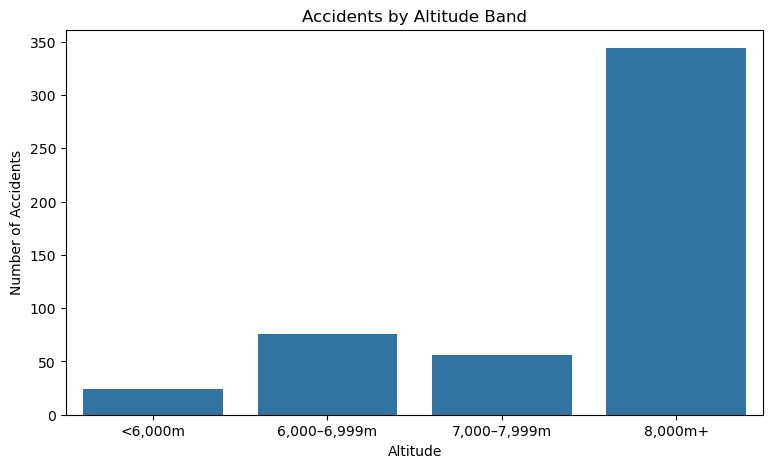

In [28]:
# Visualisation

plt.figure(figsize=(9, 5))

sns.barplot(
    data=altitude_analysis.reset_index(),
    x='Altitude_Band',
    y='Accidents'
)

plt.title('Accidents by Altitude Band')
plt.xlabel('Altitude')
plt.ylabel('Number of Accidents')
plt.savefig("Accidents by Altitude Band.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Death Zone

death_zone = (
    df_clean['Death_Zone']
    .value_counts()
    .reset_index()
)

death_zone.columns = ['Zone', 'Accidents']

death_zone['Percentage'] = (
    death_zone['Accidents'] / len(df_clean) * 100
)

death_zone

,Zone,Accidents,Percentage
0,"Death Zone (8,000m+)",344,68.8
1,Below Death Zone,156,31.2


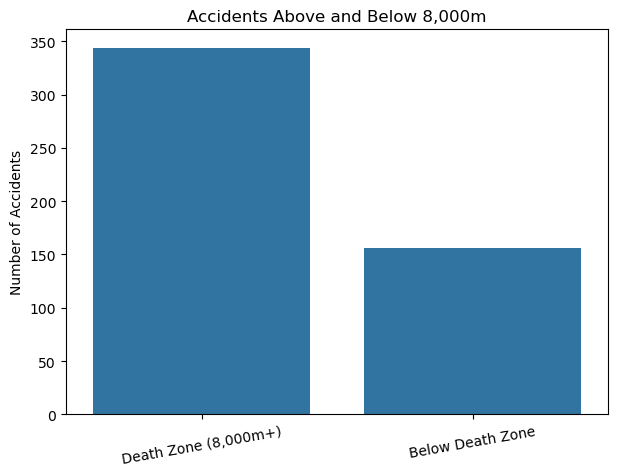

In [30]:
# Visualisation

plt.figure(figsize=(7, 5))

sns.barplot(
    data=death_zone,
    x='Zone',
    y='Accidents'
)

plt.title('Accidents Above and Below 8,000m')
plt.xlabel('')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=10)
plt.savefig("Death Zone.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# Season

season_analysis = (
    df_clean
    .groupby('Season')
    .agg(
        Accidents=('Name', 'size'),
        Average_Altitude=('Altitude_meters', 'mean'),
        Average_Age=('Age', 'mean')
    )
    .sort_values('Accidents', ascending=False)
    .round(1)
)

season_analysis

,Accidents,Average_Altitude,Average_Age
Season,,,
Summer (Jun-Aug),193,7771.8,35.5
Winter (Dec-Feb),128,7882.5,38.2
Spring (Apr-May),91,7746.3,36.3
Autumn (Oct-Nov),88,7735.4,35.0


In [32]:
# Weather conditions

weather_analysis = (
    df_clean
    .groupby('Weather_Conditions')
    .agg(
        Accidents=('Name', 'size'),
        Average_Altitude=('Altitude_meters', 'mean')
    )
    .sort_values('Accidents', ascending=False)
    .round(1)
)

weather_analysis

,Accidents,Average_Altitude
Weather_Conditions,,
Extreme cold,75,7780.3
Mixed conditions,66,7721.1
Cloudy,63,7584.7
High winds,63,7893.0
Blizzard,60,7963.6
Clear,60,7618.7
Snowstorm,57,7836.8
Whiteout,56,7941.1


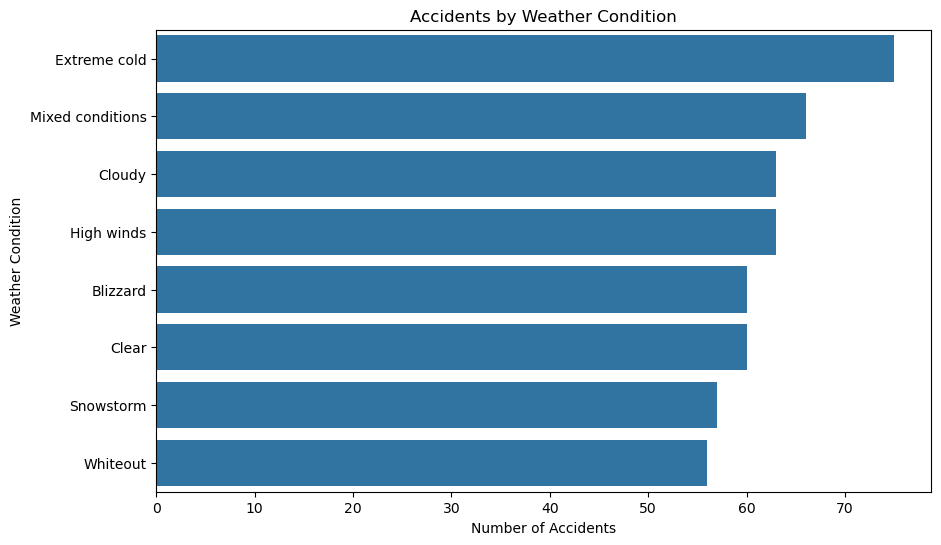

In [33]:
# Visualisation

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_analysis.reset_index(),
    x='Accidents',
    y='Weather_Conditions'
)

plt.title('Accidents by Weather Condition')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.savefig("Accidents by Weather Condition.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# Experience level

experience_analysis = (
    df_clean
    .groupby('Experience_Level')
    .agg(
        Accidents=('Name', 'size'),
        Average_Age=('Age', 'mean'),
        Average_Altitude=('Altitude_meters', 'mean')
    )
    .sort_values('Accidents', ascending=False)
    .round(1)
)

experience_analysis

,Accidents,Average_Age,Average_Altitude
Experience_Level,,,
Novice (First 8000m peak),94,36.4,7791.5
Experienced (3-5 previous 8000m peaks),86,35.6,7821.7
Expert (6+ previous 8000m peaks),85,35.9,7773.8
Intermediate (1-2 previous 8000m peaks),85,34.1,7876.6
Sherpa,76,38.0,7614.9
Professional Guide,74,38.0,7844.2


In [35]:
# Gender

gender_analysis = (
    df_clean
    .groupby('Gender')
    .agg(
        Accidents=('Name', 'size'),
        Average_Age=('Age', 'mean'),
        Average_Altitude=('Altitude_meters', 'mean')
    )
    .round(1)
)

gender_analysis

,Accidents,Average_Age,Average_Altitude
Gender,,,
Female,248,36.4,7738.2
Male,252,36.1,7839.2


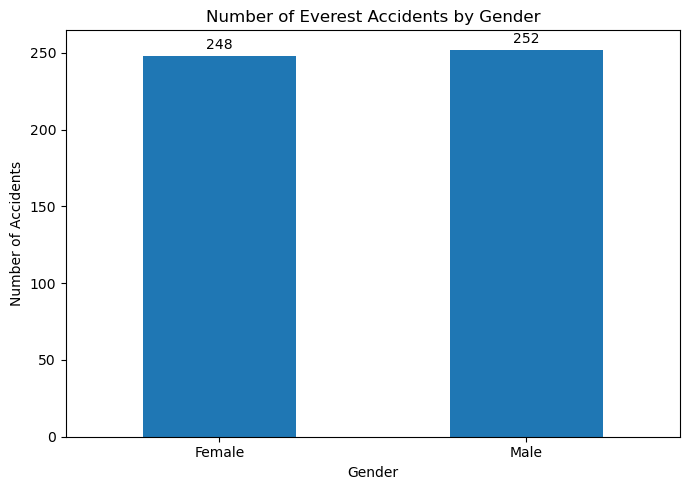

In [36]:
# Visulisation 

import matplotlib.pyplot as plt

ax = gender_analysis['Accidents'].plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Number of Everest Accidents by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)

# Add values above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("Number of Everest Accidents by Gender.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# Routes

route_analysis = (
    df_clean
    .groupby('Route')
    .agg(
        Accidents=('Name', 'size'),
        Average_Altitude=('Altitude_meters', 'mean')
    )
    .sort_values('Accidents', ascending=False)
    .round(1)
)

route_analysis

,Accidents,Average_Altitude
Route,,
East Face,88,7746.5
Southwest Face,87,7843.0
South Col Route (Nepal),86,7840.1
North Face,81,7710.1
Northeast Ridge Route (Tibet),79,7808.2
West Ridge,79,7783.7


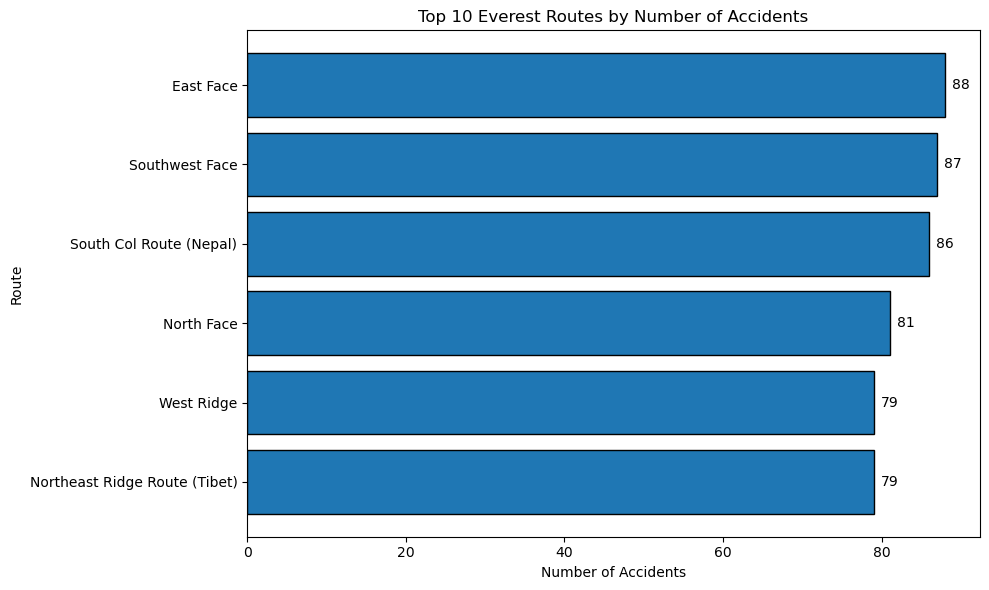

In [39]:
# Visulisation 

top_routes = route_analysis.head(10).sort_values('Accidents')

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_routes.index,
    top_routes['Accidents'],
    edgecolor='black'
)

plt.title('Top 10 Everest Routes by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Route')

plt.bar_label(bars, padding=5, fmt='%d')

plt.tight_layout()
plt.savefig("Top 10 Everest Routes by Number of Accidents.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Nationality

nationality_analysis = (
    df_clean['Nationality']
    .value_counts()
    .reset_index()
)

nationality_analysis.columns = [
    'Nationality',
    'Accidents'
]

nationality_analysis.head(10)

,Nationality,Accidents
0,Switzerland,31
1,South Africa,26
2,South Korea,22
3,United States,22
4,Russia,22
5,Brazil,21
6,Argentina,20
7,Norway,19
8,Denmark,19
9,Czech Republic,19


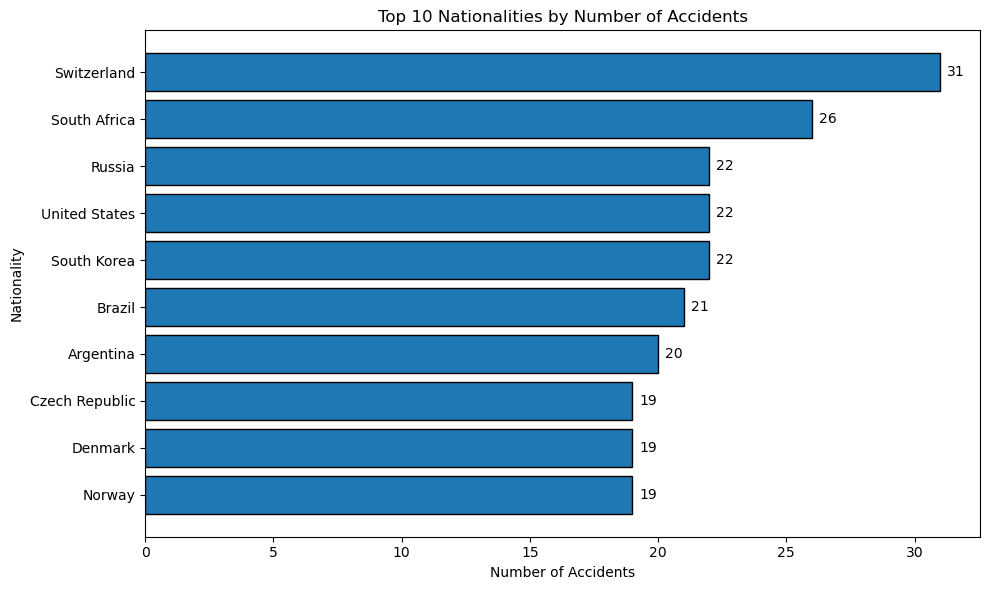

In [41]:
# Visulisation

top_nationalities = (
    nationality_analysis
    .head(10)
    .sort_values('Accidents')
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_nationalities['Nationality'],
    top_nationalities['Accidents'],
    edgecolor='black'
)

ax.set_title('Top 10 Nationalities by Number of Accidents')
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Nationality')

ax.bar_label(
    bars,
    labels=top_nationalities['Accidents'].astype(int),
    padding=5
)

plt.tight_layout()
plt.savefig("Top 10 Nationalities by Number of Accidents.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
# Expedition companies

company_analysis = (
    df_clean['Expedition_Company']
    .value_counts()
    .reset_index()
)

company_analysis.columns = [
    'Expedition_Company',
    'Accidents'
]

company_analysis.head(10)

,Expedition_Company,Accidents
0,Climbing the Seven Summits,39
1,International Mountain Guides,38
2,Furtenbach Adventures,38
3,Peak Freaks,37
4,Mountain Madness,36
5,Altitude Junkies,33
6,Summit Climb,33
7,Adventure Consultants,33
8,Alpine Ascents,32
9,Jagged Globe,30


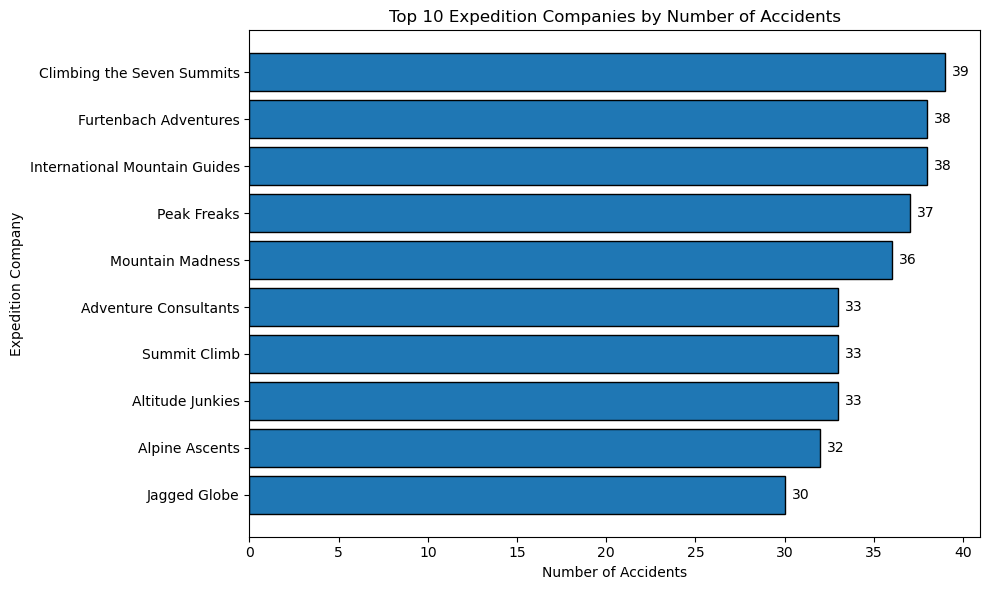

In [43]:
# Visulisation

top_companies = (
    company_analysis
    .head(10)
    .sort_values('Accidents')
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_companies['Expedition_Company'],
    top_companies['Accidents'],
    edgecolor='black'
)

ax.set_title('Top 10 Expedition Companies by Number of Accidents')
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Expedition Company')

ax.bar_label(
    bars,
    labels=top_companies['Accidents'].astype(int),
    padding=5
)

plt.tight_layout()
plt.savefig("Top 10 Expedition Companies by Number of Accidents.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Location

location_analysis = (
    df_clean['Location']
    .value_counts()
    .reset_index()
)

location_analysis.columns = [
    'Location',
    'Accidents'
]

location_analysis.head(15)

,Location,Accidents
0,Khumbu Icefall,49
1,Camp 4 (South Col - 8000m),41
2,Western Cwm,41
3,Camp 2 (6400m),38
4,South Summit (8750m),36
5,Balcony (8400m),35
6,Yellow Band,35
7,Camp 1 (6065m),33
8,Summit (8848m),32
9,Death Zone (above 8000m),31


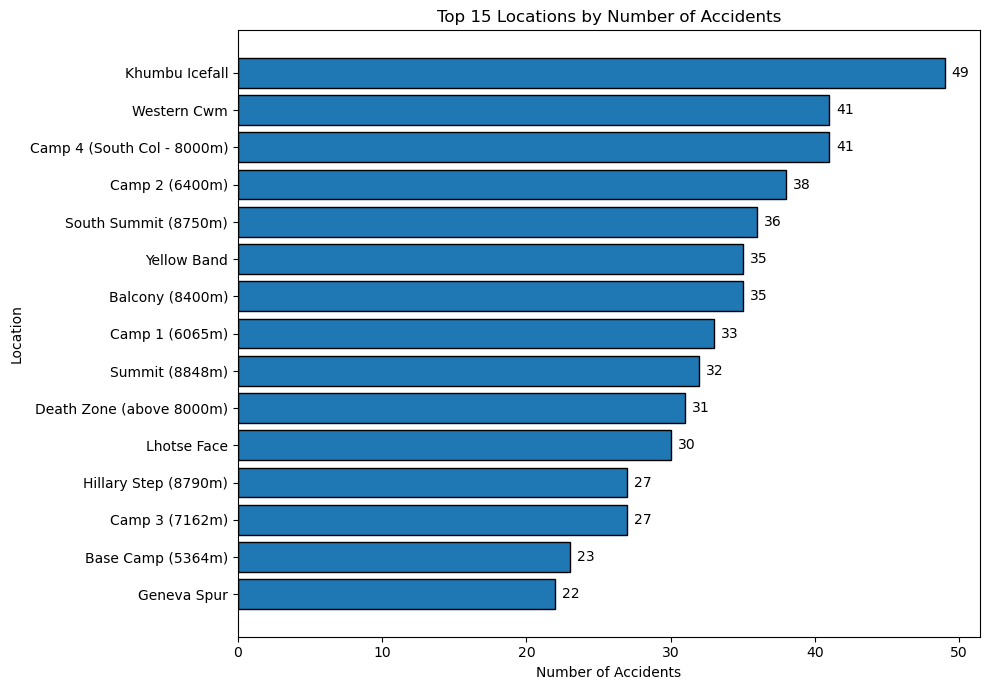

In [46]:
# Visulisation 

top_locations = (
    location_analysis
    .head(15)
    .sort_values('Accidents')
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_locations['Location'],
    top_locations['Accidents'],
    edgecolor='black'
)

ax.set_title('Top 15 Locations by Number of Accidents')
ax.set_xlabel('Number of Accidents')
ax.set_ylabel('Location')

ax.bar_label(
    bars,
    labels=top_locations['Accidents'].astype(int),
    padding=5
)

plt.tight_layout()
plt.savefig("Top 15 Locations by Number of Accidents.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# Cause of death by altitude

cause_altitude = pd.crosstab(
    df_clean['Altitude_Band'],
    df_clean['Cause_of_Death'],
    normalize='index'
) * 100

cause_altitude.round(1)

Cause_of_Death,Altitude Sickness (AMS/HAPE/HACE),Avalanche,Cerebral edema,Crevasse fall,Disorientation/Lost,Equipment failure,Exhaustion,Falling,Frostbite complications,Hypothermia,Icefall,Pulmonary edema,Rockfall,Sudden cardiac event,Weather exposure
Altitude_Band,,,,,,,,,,,,,,,
"<6,000m",4.2,4.2,8.3,8.3,4.2,0.0,12.5,20.8,12.5,8.3,4.2,4.2,4.2,4.2,0.0
"6,000–6,999m",14.5,9.2,5.3,11.8,1.3,2.6,5.3,18.4,5.3,5.3,7.9,1.3,7.9,1.3,2.6
"7,000–7,999m",8.9,16.1,1.8,5.4,1.8,5.4,7.1,19.6,8.9,10.7,3.6,3.6,0.0,5.4,1.8
"8,000m+",32.6,5.5,3.8,1.5,1.5,1.2,20.3,8.1,4.4,8.7,2.0,1.5,2.3,4.9,1.7


In [48]:
# Season vs cause

season_cause = pd.crosstab(
    df_clean['Season'],
    df_clean['Cause_of_Death']
)

season_cause

Cause_of_Death,Altitude Sickness (AMS/HAPE/HACE),Avalanche,Cerebral edema,Crevasse fall,Disorientation/Lost,Equipment failure,Exhaustion,Falling,Frostbite complications,Hypothermia,Icefall,Pulmonary edema,Rockfall,Sudden cardiac event,Weather exposure
Season,,,,,,,,,,,,,,,
Autumn (Oct-Nov),18,9,8,2,0,3,14,8,3,9,2,3,2,6,1
Spring (Apr-May),25,8,4,4,1,1,12,12,4,8,3,1,1,4,3
Summer (Jun-Aug),56,9,6,8,4,3,30,19,15,14,9,4,6,8,2
Winter (Dec-Feb),30,10,2,5,3,2,25,19,5,11,2,1,6,4,3


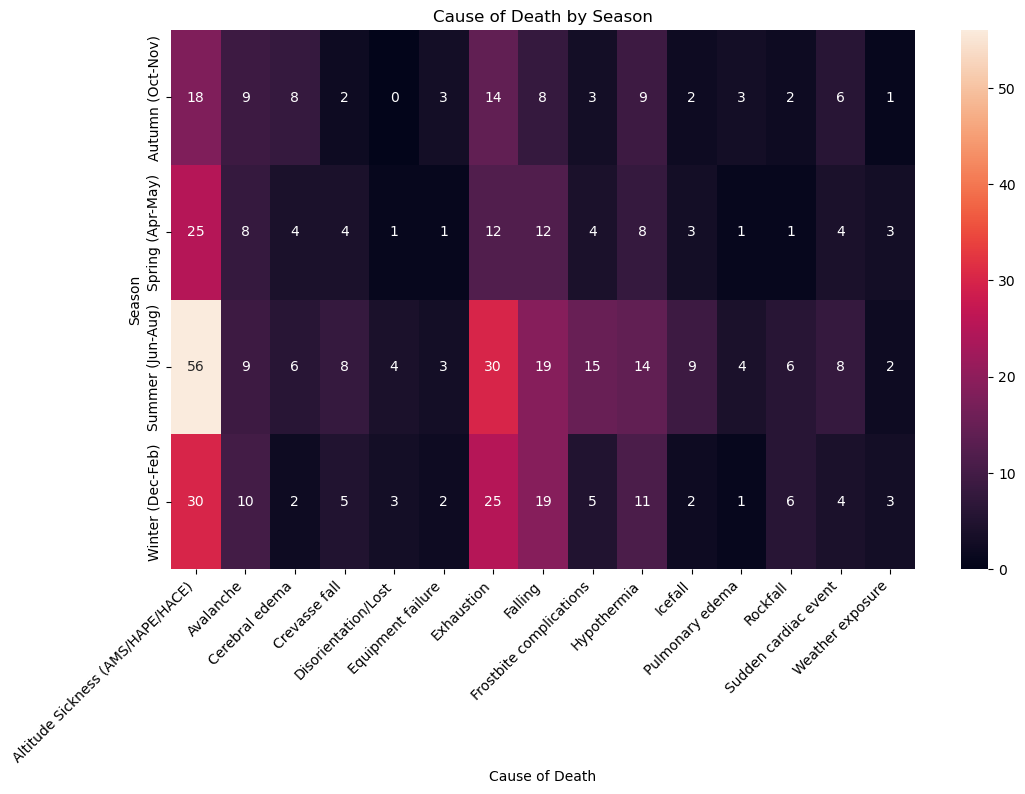

In [49]:
# Visulisation

plt.figure(figsize=(12, 7))

sns.heatmap(
    season_cause,
    annot=True,
    fmt='d'
)

plt.title('Cause of Death by Season')
plt.xlabel('Cause of Death')
plt.ylabel('Season')

plt.xticks(rotation=45, ha='right')
plt.savefig("Cause of Death by Season.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Weather vs cause

weather_cause = pd.crosstab(
    df_clean['Weather_Conditions'],
    df_clean['Cause_of_Death']
)

weather_cause

Cause_of_Death,Altitude Sickness (AMS/HAPE/HACE),Avalanche,Cerebral edema,Crevasse fall,Disorientation/Lost,Equipment failure,Exhaustion,Falling,Frostbite complications,Hypothermia,Icefall,Pulmonary edema,Rockfall,Sudden cardiac event,Weather exposure
Weather_Conditions,,,,,,,,,,,,,,,
Blizzard,15,4,1,1,1,0,14,9,2,6,2,1,1,2,1
Clear,10,3,2,3,2,1,11,5,5,9,1,1,1,6,0
Cloudy,21,2,4,1,1,2,7,10,5,1,3,1,3,1,1
Extreme cold,19,5,4,3,1,0,9,8,5,12,1,1,2,5,0
High winds,16,9,4,2,2,2,10,3,1,5,1,1,3,2,2
Mixed conditions,20,6,1,2,0,3,8,11,1,4,3,2,2,2,1
Snowstorm,12,4,2,1,0,1,13,8,4,3,3,1,1,4,0
Whiteout,16,3,2,6,1,0,9,4,4,2,2,1,2,0,4


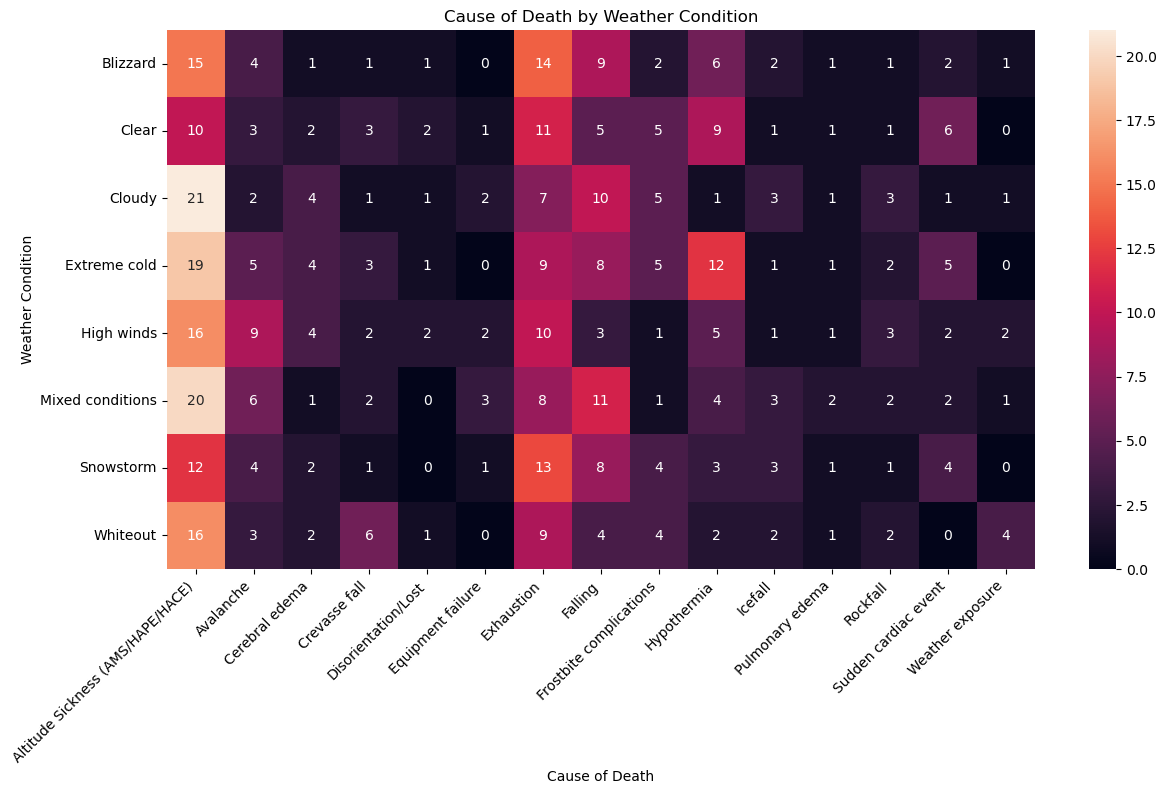

In [51]:
# Visualisation

plt.figure(figsize=(14, 7))

sns.heatmap(
    weather_cause,
    annot=True,
    fmt='d'
)

plt.title('Cause of Death by Weather Condition')
plt.xlabel('Cause of Death')
plt.ylabel('Weather Condition')

plt.xticks(rotation=45, ha='right')
plt.savefig("Cause of Death by Weather Condition.png", dpi=300, bbox_inches="tight")
plt.show()

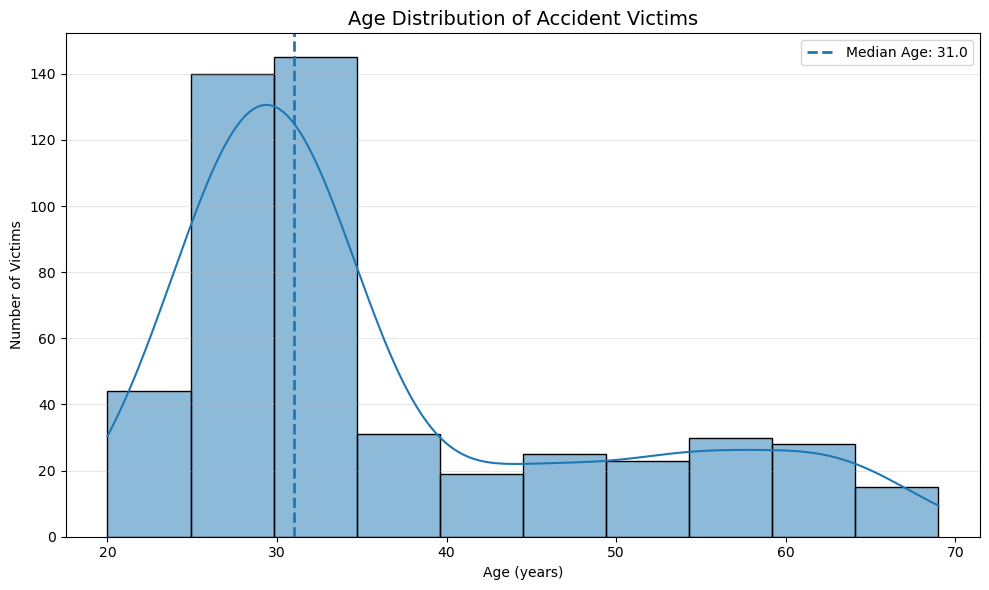

In [52]:
# Age distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x='Age',
    bins=10,
    kde=True,
    edgecolor='black'
)

# Add median age line
median_age = df_clean['Age'].median()

plt.axvline(
    median_age,
    linestyle='--',
    linewidth=2,
    label=f'Median Age: {median_age:.1f}'
)

plt.title('Age Distribution of Accident Victims', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Number of Victims')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("Age Distribution of Accident Victims.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
# Age group analysis

age_analysis = (
    df_clean['Age_Group']
    .value_counts()
    .sort_index()
    .reset_index()
)

age_analysis.columns = [
    'Age_Group',
    'Accidents'
]

age_analysis

,Age_Group,Accidents
0,20–29,184
1,30–39,176
2,40–49,44
3,50–59,53
4,60+,43


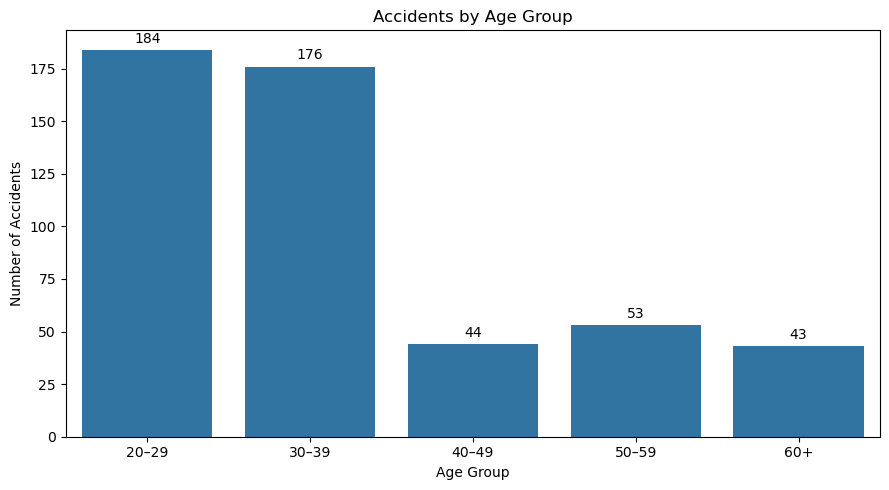

In [54]:
# Visualisation

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=age_analysis,
    x='Age_Group',
    y='Accidents'
)

plt.title('Accidents by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

plt.tight_layout()
plt.savefig("Accidents by Age Group.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
# Correlation analysis 

correlation = df_clean[
    ['Age', 'Altitude_meters', 'Year']
].corr()

correlation.round(3)

,Age,Altitude_meters,Year
Age,1.000,0.010,-0.042
Altitude_meters,0.010,1.000,0.005
Year,-0.042,0.005,1.000


Correlation Analysis: This means older individuals are not systematically represented at substantially higher or lower accident altitudes.

In [58]:
# Highest-risk recorded combination

combination_analysis = (
    df_clean
    .groupby([
        'Altitude_Band',
        'Weather_Conditions',
        'Cause_of_Death'
    ])
    .size()
    .reset_index(name='Accidents')
    .sort_values('Accidents', ascending=False)
)

combination_analysis.head(15)

,Altitude_Band,Weather_Conditions,Cause_of_Death,Accidents
405,"8,000m+",Extreme cold,Altitude Sickness (AMS/HAPE/HACE),19
435,"8,000m+",Mixed conditions,Altitude Sickness (AMS/HAPE/HACE),18
390,"8,000m+",Cloudy,Altitude Sickness (AMS/HAPE/HACE),15
465,"8,000m+",Whiteout,Altitude Sickness (AMS/HAPE/HACE),14
360,"8,000m+",Blizzard,Altitude Sickness (AMS/HAPE/HACE),13
420,"8,000m+",High winds,Altitude Sickness (AMS/HAPE/HACE),13
366,"8,000m+",Blizzard,Exhaustion,13
450,"8,000m+",Snowstorm,Altitude Sickness (AMS/HAPE/HACE),12
456,"8,000m+",Snowstorm,Exhaustion,12
426,"8,000m+",High winds,Exhaustion,9


In [59]:
# Altitude sickness by weather

ams_analysis = (
    df_clean[
        df_clean['Cause_of_Death'] ==
        'Altitude Sickness (AMS/HAPE/HACE)'
    ]
    .groupby('Weather_Conditions')
    .size()
    .reset_index(name='Altitude_Sickness_Cases')
    .sort_values(
        'Altitude_Sickness_Cases',
        ascending=False
    )
)

ams_analysis

,Weather_Conditions,Altitude_Sickness_Cases
2,Cloudy,21
5,Mixed conditions,20
3,Extreme cold,19
4,High winds,16
7,Whiteout,16
0,Blizzard,15
6,Snowstorm,12
1,Clear,10
